## Regression tree and HP optimization
## Data
Source: [https://www.kaggle.com/datasets/mirichoi0218/insurance]

Individual medical costs billed by health insurance

EDA: e.g [https://datauab.github.io/medical_insurance/]

In this notebook, we will demonstrate basic syntax of **scikit** library.
There are many popular data science modes in this library.

The basic syntax is a **instantiate->fit->predict** sequence.

In [1]:
### Dependencies
import pandas as pd #data frames and other stuff
import matplotlib.pyplot as plt #basic graphs
import pickle


# Usefull functions
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error # MSE

# Used models
from sklearn.tree import DecisionTreeRegressor

We will use the insurance data preprocessed and stored in the pickle file.
Remeber that 4 variables (X_train,X_test, y_train, y_test) are stored in the pickle file.

In [3]:
# import gdown # to download files from Google Drive
#In colab, you need to download the file first and save it locally
# file_id = '1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9' #insurance.pkl
file_path = '../data/insurance_train_test.pkl'
# gdown.download('https://drive.google.com/uc?id={}'.format(file_id), file_path, quiet=False)

In [4]:
#Load the data
#for local installation / VM horizon
file_path = '../data/insurance_train_test.pkl'

#load data (already split into training and validation)
with open(file_path, "rb") as input_file:
    X_train,X_test, y_train, y_test = pickle.load(input_file)

## Instantiate the model
Scikit models have default values of hyper parameters (HP).

You can find the specific values in the documentation.

You may override some of them in the instantiation phase. You may pass the mirectly to the model function or store them in a dictionary and pass the dictionary to the function.

In [5]:
#Set keyword arguments defined outside function a dictionary {"": }
#Or you can be also set them directly in DecisionTreeRegressor function

HP = {"max_depth":2,
      "min_samples_leaf":0.05,
      }

# Instantiate decision tree regressor and assign it to 'tree_model'
tree_model = DecisionTreeRegressor(
    **HP #**denotes key word args
    )

## Fit the model
Next you can fit the model.

You need to pass the features and the target data to the fit() function.

This is the function that is computationally the most demanding as it actually trains the model.

[Text(0.5, 0.8333333333333334, 'smoker_yes <= 0.5\nsquared_error = 148415109.793\nsamples = 1070\nvalue = 13524.021'),
 Text(0.25, 0.5, 'age <= 42.5\nsquared_error = 37541120.13\nsamples = 849\nvalue = 8664.916'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 24659510.327\nsamples = 467\nvalue = 5632.825'),
 Text(0.375, 0.16666666666666666, 'squared_error = 28309642.635\nsamples = 382\nvalue = 12371.686'),
 Text(0.75, 0.5, 'bmi <= 30.05\nsquared_error = 135195077.85\nsamples = 221\nvalue = 32190.902'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 25445573.129\nsamples = 106\nvalue = 21574.301'),
 Text(0.875, 0.16666666666666666, 'squared_error = 36703605.137\nsamples = 115\nvalue = 41976.638')]

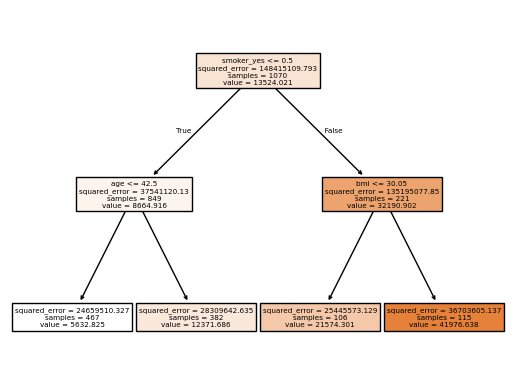

In [6]:
# Fit 'tree_model' to the training set
tree_model.fit(X_train, y_train)

#plot the tree
tree.plot_tree(tree_model,
               feature_names=list(X_train.columns),
               class_names=list(y_train.columns),
               filled=True)

## Predict the model
Now you will probably want to calculate the predictions and perhaps some evaluation measures.

We will look at the root mean squared error RMSE.

In [7]:
#Calculate predictions for the test data
y_pred = tree_model.predict(X_test)

#Calculate the RMSE
rmse = root_mean_squared_error(y_test, y_pred)

print(f"RMSE: {rmse}")


RMSE: 4194.815678828533


## Optimize the hyper parameters using the grid search and cross validation

The tree we fitted is very small. Even for such small data. We are probably underfitting.

We should try several combinations of HP values and calculate validation RMSE and find the best combination.

We will use the GridSearchCV() fucntion that will create the combinations, and perform the cross-validation for us.

The grid over which we will optimize is defined again in a dictionary. This time, however, several values are set for each HP in a list.

In [8]:
#Set the grid of values for the hyperparameters to be combined
hyper_grid = {"max_depth": [2, 3, 5, 10, 20],
               "min_samples_leaf": [0.01, 0.05, 0.1],
               }

Note that we have 5*3 combinations of the HP. Furthermore if we do 3 fold cross  validation, the model is fitted 45 times. Luckily, we have a small dataset and small model but the number of combinations increases very fast with increasing number of HPs and its values.

In [9]:
#instantiate the model with no HP
tree_model_cv = DecisionTreeRegressor()

# Instantiate the grid search model that uses the tree_model_cv model and the hyper_grid
grid_search = GridSearchCV(estimator = tree_model_cv,
                          param_grid = hyper_grid,
                          cv = 3,
                          n_jobs = -1,
                          verbose = 2
                          )

# Fit the grid search to the data
grid_search.fit(X_train, y_train.values)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


[CV] END .................max_depth=2, min_samples_leaf=0.01; total time=   0.0s
[CV] END ..................max_depth=2, min_samples_leaf=0.1; total time=   0.0s
[CV] END .................max_depth=2, min_samples_leaf=0.01; total time=   0.0s
[CV] END .................max_depth=3, min_samples_leaf=0.01; total time=   0.0s
[CV] END .................max_depth=3, min_samples_leaf=0.01; total time=   0.1s
[CV] END .................max_depth=3, min_samples_leaf=0.01; total time=   0.0s
[CV] END .................max_depth=3, min_samples_leaf=0.05; total time=   0.0s
[CV] END .................max_depth=3, min_samples_leaf=0.05; total time=   0.0s
[CV] END .................max_depth=3, min_samples_leaf=0.05; total time=   0.0s
[CV] END ..................max_depth=3, min_samples_leaf=0.1; total time=   0.0s
[CV] END ..................max_depth=3, min_samples_leaf=0.1; total time=   0.0s
[CV] END ..................max_depth=3, min_samples_leaf=0.1; total time=   0.0s
[CV] END .................ma

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [0.01, 0.05, 0.1]},
             verbose=2)

The GridSearchCV function saves the best combination found.

It also trains the model with the best combination on all data. (No validation split is done in thsi final step.)

The model is already fitted. You do not need to fit it again.

{'max_depth': 3, 'min_samples_leaf': 0.01}
3825.624694230376


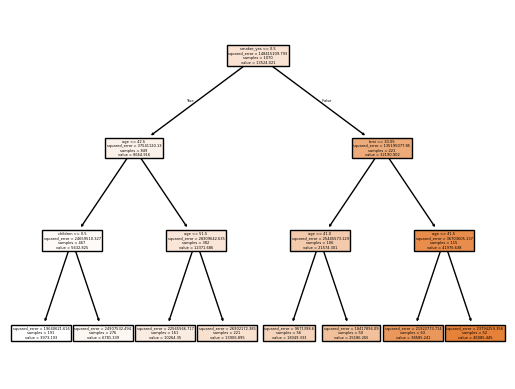

In [10]:
#Print the best hyperparameters
print(grid_search.best_params_)
#Extract the best model
model_cv_opt= grid_search.best_estimator_

#Plot the optimized three
best_tree_model = grid_search.best_estimator_
tree.plot_tree(best_tree_model,
               feature_names=list(X_train.columns),
               class_names=list(y_train.columns),
               filled=True)


#The model is already fitted. No need to fit it again
y_pred_cv = model_cv_opt.predict(X_test)

#rmse on testing data
rmse_model_cv = root_mean_squared_error(y_test, y_pred_cv)
print(rmse_model_cv)

We were able to **improve the RMSE by this optimization** procedure.

## Post pruning

Out of scope of the course.

Please check the references for details.

Driven by ccp_alpha (default=0.0)

Complexity parameter used for Minimal Cost-Complexity Pruning.

The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen. By default, no pruning is performed.

[https://scikit-learn.org/stable/modules/tree.html#minimal-cost-complexity-pruning]

[https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html]

or

[https://www.analyticsvidhya.com/blog/2020/10/cost-complexity-pruning-decision-trees/]